<a href="https://colab.research.google.com/github/pratikchopade21-a11y/IPCV-Lab/blob/main/IPCV_Exp_07.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Name:-Pratik Mahesh Chopade
#Roll No.:- TY AIML B59
#PRN:- 2324001102
#IPCV Exp. 07:-Face Detection and Recognition using OpenCV  

In [ ]:
!pip uninstall -y opencv-python
!pip install opencv-contrib-python

Found existing installation: opencv-python 4.13.0.92
Uninstalling opencv-python-4.13.0.92:
  Successfully uninstalled opencv-python-4.13.0.92


In [ ]:
!pip install opencv-contrib-python

In [ ]:
#Upload kaggle.json
from google.colab import files
files.upload()

Saving kaggle (1).json to kaggle (1).json


{'kaggle (1).json': b'{"username":"pratik212500","key":"5d9f936d3209f83c030df1cdf1d5a88e"}'}

In [ ]:
#Set Kaggle APIimport os

import os

os.makedirs("/root/.kaggle", exist_ok=True)

!cp kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [ ]:
#Download Dataset
!kaggle datasets download -d hereisburak/pins-face-recognition

Dataset URL: https://www.kaggle.com/datasets/hereisburak/pins-face-recognition
License(s): CC0-1.0
100% 372M/372M [00:02<00:00, 172MB/s]



In [ ]:
#Unzip Dataset
!unzip pins-face-recognition.zip -d face_dataset

Streaming output truncated to the last 5000 lines.
  inflating: face_dataset/105_classes_pins_dataset/pins_Sophie Turner/Sophie Turner37_964.jpg  
  inflating: face_dataset/105_classes_pins_dataset/pins_Sophie Turner/Sophie Turner38_965.jpg  
  inflating: face_dataset/105_classes_pins_dataset/pins_Sophie Turner/Sophie Turner39_966.jpg  
  inflating: face_dataset/105_classes_pins_dataset/pins_Sophie Turner/Sophie Turner3_956.jpg  
  inflating: face_dataset/105_classes_pins_dataset/pins_Sophie Turner/Sophie Turner41_968.jpg  
  inflating: face_dataset/105_classes_pins_dataset/pins_Sophie Turner/Sophie Turner42_969.jpg  
  inflating: face_dataset/105_classes_pins_dataset/pins_Sophie Turner/Sophie Turner44_970.jpg  
  inflating: face_dataset/105_classes_pins_dataset/pins_Sophie Turner/Sophie Turner45_971.jpg  
  inflating: face_dataset/105_classes_pins_dataset/pins_Sophie Turner/Sophie Turner46_972.jpg  
  inflating: face_dataset/105_classes_pins_dataset/pins_Sophie Turner/Sophie Turner47_

In [ ]:
#Check Dataset
import os

print(os.listdir("/content/face_dataset"))

['105_classes_pins_dataset']


In [ ]:
dataset_path = "/content/face_dataset/105_classes_pins_dataset"

In [ ]:
# Import Libraries
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
#Load Haar Cascade Face Detector
haar_path = cv2.data.haarcascades + "haarcascade_frontalface_default.xml"

face_detector = cv2.CascadeClassifier(haar_path)

if face_detector.empty():
    print("Error loading Haar cascade file")
else:
    print("Haar cascade loaded successfully")

Haar cascade loaded successfully


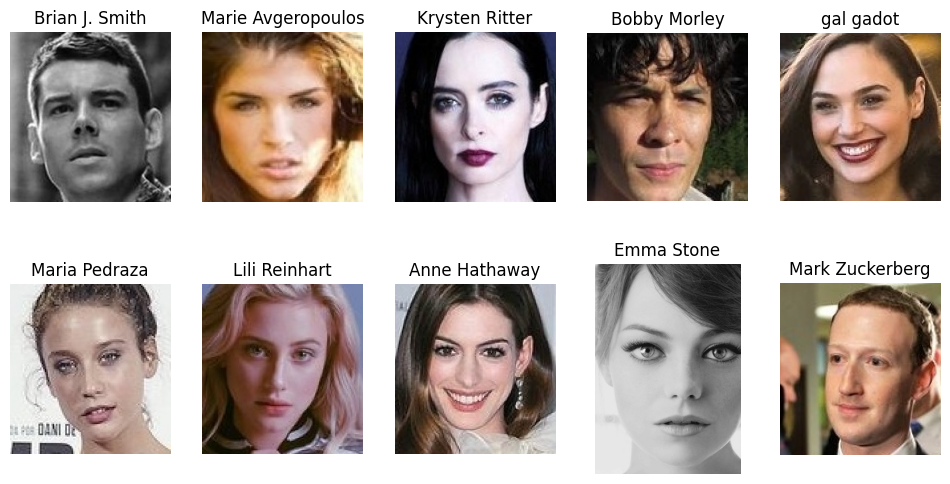

In [ ]:
# Fix dataset path and display sample images
dataset_path = "/content/face_dataset/105_classes_pins_dataset"

plt.figure(figsize=(12, 6))
count = 1

if not os.path.exists(dataset_path):
    print(f"Error: Path {dataset_path} does not exist.")
else:
    for person_name in os.listdir(dataset_path):
        person_folder = os.path.join(dataset_path, person_name)
        if not os.path.isdir(person_folder): continue

        for image_name in os.listdir(person_folder)[:1]:
            image_path = os.path.join(person_folder, image_name)
            image = cv2.imread(image_path)
            if image is None: continue

            image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            plt.subplot(2, 5, count)
            plt.imshow(image_rgb)
            plt.title(person_name.replace('pins_', ''))
            plt.axis("off")
            count += 1
            if count > 10: break
        if count > 10: break
    plt.show()

In [ ]:
#Prepare Training Data
def prepare_training_data(dataset_path):
    faces = []
    labels = []
    label_map = {}
    current_label = 0

    for person_name in os.listdir(dataset_path):
        person_folder = os.path.join(dataset_path, person_name)

        if not os.path.isdir(person_folder):
            continue

        label_map[current_label] = person_name

        for image_name in os.listdir(person_folder):
            image_path = os.path.join(person_folder, image_name)

            image = cv2.imread(image_path)

            if image is None:
                continue

            gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

            detected_faces = face_detector.detectMultiScale(
                gray,
                scaleFactor=1.1,
                minNeighbors=5,
                minSize=(50, 50)
            )

            if len(detected_faces) == 0:
                continue

            x, y, w, h = detected_faces[0]

            face_roi = gray[y:y+h, x:x+w]
            face_roi = cv2.resize(face_roi, (200, 200))

            faces.append(face_roi)
            labels.append(current_label)

        current_label += 1

    return faces, np.array(labels), label_map

In [ ]:
# Re-run data preparation with corrected path
print("Processing images, please wait...")
faces, labels, label_map = prepare_training_data(dataset_path)

print("Total faces detected:", len(faces))
print("Total labels:", len(labels))
if len(faces) > 0:
    print("Success! Data prepared for training.")

Processing images, please wait...
Total faces detected: 15372
Total labels: 15372
Success! Data prepared for training.


In [ ]:
#Show Detected Faces Used for Training
plt.figure(figsize=(12, 6))

for i in range(min(10, len(faces))):
    plt.subplot(2, 5, i + 1)
    plt.imshow(faces[i], cmap="gray")
    plt.title(label_map[labels[i]])
    plt.axis("off")

plt.show()

<Figure size 1200x600 with 0 Axes>

In [ ]:
# Train LBPH Face Recognizer
print(f"Training with {len(faces)} faces...")

try:
    recognizer = cv2.face.LBPHFaceRecognizer_create()
    recognizer.train(faces, labels)
    print("Face recognition model trained successfully!")
except AttributeError:
    print("Error: cv2.face not found. Please run '!pip install opencv-contrib-python' and then 'Runtime -> Restart session'.")
except Exception as e:
    print(f"An error occurred during training: {e}")

Training with 15372 faces...
Error: cv2.face not found. Please run '!pip install opencv-contrib-python' and then 'Runtime -> Restart session'.


In [ ]:
import cv2
import sys

# Diagnostic: Ensure we are using the contrib version
print(f"OpenCV Version: {cv2.__version__}")

try:
    # Check if 'face' is available in cv2
    recognizer = cv2.face.LBPHFaceRecognizer_create()
    print("✅ Success! cv2.face is now available.")

    if 'faces' in globals() and 'labels' in globals():
        print(f"Training model on {len(faces)} samples...")
        recognizer.train(faces, labels)
        print("Model training complete!")
    else:
        print("Environment is fixed, but 'faces' and 'labels' are missing from memory.")
        print("Please re-run your data preparation cells above.")

except AttributeError:
    print("❌ Error: cv2.face still not found.")
    print("This happens because the previous library version is still in memory.")
    print("CRITICAL: Go to 'Runtime' -> 'Restart session' now.")

OpenCV Version: 4.13.0
❌ Error: cv2.face still not found.
This happens because the previous library version is still in memory.
CRITICAL: Go to 'Runtime' -> 'Restart session' now.


In [ ]:
import os
# This command kills the current process, causing Colab to automatically restart the runtime.
os._exit(00)

In [ ]:
import cv2
import os
import numpy as np

# 1. Setup paths and detector
try:
    haar_path = cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
    face_detector = cv2.CascadeClassifier(haar_path)
    print(f"OpenCV {cv2.__version__} ready.")
except AttributeError:
    print("Still hitting an import error. Please ensure you have selected 'Runtime' -> 'Restart session' above.")

dataset_path = '/content/face_dataset/105_classes_pins_dataset'

def prepare_data(path):
    faces, labels = [], []
    print("Starting data preparation (15k+ images)...")
    folders = sorted([f for f in os.listdir(path) if os.path.isdir(os.path.join(path, f))])
    for i, person in enumerate(folders):
        folder = os.path.join(path, person)
        for img_name in os.listdir(folder):
            img = cv2.imread(os.path.join(folder, img_name))
            if img is None: continue
            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            detections = face_detector.detectMultiScale(gray, 1.1, 5, minSize=(50, 50))
            if len(detections) > 0:
                x, y, w, h = detections[0]
                faces.append(cv2.resize(gray[y:y+h, x:x+w], (200, 200)))
                labels.append(i)
        if i % 10 == 0: print(f"Processed {i}/{len(folders)} classes...")
    return faces, np.array(labels)

# 2. Run Preparation and Training
try:
    faces, labels = prepare_data(dataset_path)
    print(f"Data Ready: {len(faces)} faces detected.")

    print("Training LBPH Model...")
    recognizer = cv2.face.LBPHFaceRecognizer_create()
    recognizer.train(faces, labels)
    print("✅ Success! LBPH Model trained successfully.")
except Exception as e:
    print(f"❌ An error occurred: {e}")

OpenCV 4.13.0 ready.
Starting data preparation (15k+ images)...
Processed 0/105 classes...
Processed 10/105 classes...
Processed 20/105 classes...
Processed 30/105 classes...
Processed 40/105 classes...
Processed 50/105 classes...
Processed 60/105 classes...
Processed 70/105 classes...
Processed 80/105 classes...
Processed 90/105 classes...
Processed 100/105 classes...
Data Ready: 15372 faces detected.
Training LBPH Model...
✅ Success! LBPH Model trained successfully.


✅ Model saved to 'face_recognizer_model.yml'


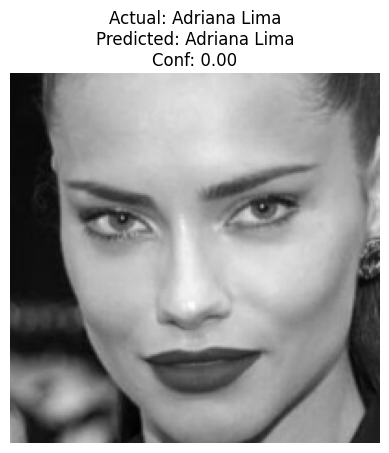

In [ ]:
import matplotlib.pyplot as plt

# 1. Save the model
recognizer.write('face_recognizer_model.yml')
print("✅ Model saved to 'face_recognizer_model.yml'")

# 2. Test Inference on a random sample
def test_recognition(sample_idx=0):
    test_img = faces[sample_idx]
    actual_label = labels[sample_idx]

    # Predict
    prediction_label, confidence = recognizer.predict(test_img)

    # Map back to person name
    folders = sorted([f for f in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, f))])
    actual_name = folders[actual_label].replace('pins_', '')
    predicted_name = folders[prediction_label].replace('pins_', '')

    plt.imshow(test_img, cmap='gray')
    plt.title(f"Actual: {actual_name}\nPredicted: {predicted_name}\nConf: {confidence:.2f}")
    plt.axis('off')
    plt.show()

# Test with a sample
test_recognition(sample_idx=100)

In [ ]:
#recognizer.save("face_recognizer_model.yml")

print("Model saved successfully")

Model saved successfully


In [ ]:
#Face Detection on a Test Image
from google.colab import files

uploaded = files.upload()

Saving test.jpeg to test.jpeg


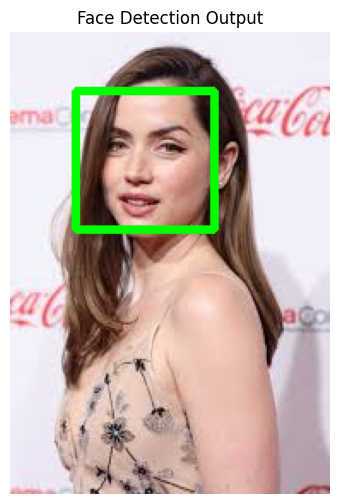

In [ ]:
test_image_path = list(uploaded.keys())[0]

image = cv2.imread(test_image_path)
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

detected_faces = face_detector.detectMultiScale(
    gray,
    scaleFactor=1.1,
    minNeighbors=5,
    minSize=(50, 50)
)

for (x, y, w, h) in detected_faces:
    cv2.rectangle(image, (x, y), (x+w, y+h), (0, 255, 0), 3)

image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8, 6))
plt.imshow(image_rgb)
plt.title("Face Detection Output")
plt.axis("off")
plt.show()

In [ ]:
#Face Recognition on Test Image
def recognize_faces(image_path):
    image = cv2.imread(image_path)
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    detected_faces = face_detector.detectMultiScale(
        gray,
        scaleFactor=1.1,
        minNeighbors=5,
        minSize=(50, 50)
    )

    for (x, y, w, h) in detected_faces:
        face_roi = gray[y:y+h, x:x+w]
        face_roi = cv2.resize(face_roi, (200, 200))

        label, confidence = recognizer.predict(face_roi)

        name = label_map[label]

        cv2.rectangle(image, (x, y), (x+w, y+h), (0, 255, 0), 3)

        text = f"{name} | Conf: {round(confidence, 2)}"

        cv2.putText(
            image,
            text,
            (x, y - 10),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.8,
            (255, 0, 0),
            2
        )

    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(8, 6))
    plt.imshow(image_rgb)
    plt.title("Face Recognition Output")
    plt.axis("off")
    plt.show()

In [ ]:
#Unknown Face Handling
def recognize_faces_with_unknown(image_path, threshold=80):
    image = cv2.imread(image_path)
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    detected_faces = face_detector.detectMultiScale(
        gray,
        scaleFactor=1.1,
        minNeighbors=5,
        minSize=(50, 50)
    )

    for (x, y, w, h) in detected_faces:
        face_roi = gray[y:y+h, x:x+w]
        face_roi = cv2.resize(face_roi, (200, 200))

        label, confidence = recognizer.predict(face_roi)

        if confidence < threshold:
            name = label_map[label]
        else:
            name = "Unknown"

        cv2.rectangle(image, (x, y), (x+w, y+h), (0, 255, 0), 3)

        text = f"{name} | {round(confidence, 2)}"

        cv2.putText(
            image,
            text,
            (x, y - 10),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.8,
            (255, 0, 0),
            2
        )

    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(8, 6))
    plt.imshow(image_rgb)
    plt.title("Face Recognition with Unknown Handling")
    plt.axis("off")
    plt.show()

In [ ]:
#Real-Time Face Recognition using Webcam(not applicable in collab)
import cv2

cap = cv2.VideoCapture(0)

while True:
    ret, frame = cap.read()

    if not ret:
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    detected_faces = face_detector.detectMultiScale(
        gray,
        scaleFactor=1.1,
        minNeighbors=5,
        minSize=(50, 50)
    )

    for (x, y, w, h) in detected_faces:
        face_roi = gray[y:y+h, x:x+w]
        face_roi = cv2.resize(face_roi, (200, 200))

        label, confidence = recognizer.predict(face_roi)

        if confidence < 80:
            name = label_map[label]
        else:
            name = "Unknown"

        cv2.rectangle(frame, (x, y), (x+w, y+h), (0, 255, 0), 2)

        cv2.putText(
            frame,
            f"{name} {round(confidence, 2)}",
            (x, y - 10),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.8,
            (0, 255, 0),
            2
        )

    cv2.imshow("Face Recognition", frame)

    if cv2.waitKey(1) & 0xFF == ord("q"):
        break

cap.release()
cv2.destroyAllWindows()